<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/paper1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:

df = pd.read_csv('/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv')

In [4]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
label_encoded = LabelEncoder()


df['Gender'] = label_encoded.fit_transform(df['Gender'])
print("\nAfter Label Encoding 'Gender':")
print(df[['Gender']])
#female=0, male=1

# Convert 'Result' column
df['Result'] = label_encoded.fit_transform(df['Result'])
print("\nAfter Label Encoding 'Result':")
print(df[['Result']])
# negative = 0, positive= 1


After Label Encoding 'Gender':
      Gender
0          1
1          1
2          1
3          0
4          1
...      ...
1518       0
1519       1
1520       1
1521       1
1522       1

[1523 rows x 1 columns]

After Label Encoding 'Result':
      Result
0          1
1          1
2          0
3          0
4          0
...      ...
1518       1
1519       1
1520       1
1521       1
1522       1

[1523 rows x 1 columns]


In [5]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Define features (X) and target (y)
X = df.drop('Result', axis=1)
y = df['Result']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✅ Data Split:")
print(f"   Training: {X_train.shape[0]} patients ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Testing:  {X_test.shape[0]} patients ({X_test.shape[0]/len(df)*100:.0f}%)")
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

✅ Data Split:
   Training: 1218 patients (80%)
   Testing:  305 patients (20%)
(1218, 18)
(305, 18)
(1218,)
(305,)


In [7]:
# Feature Scaling (IMPORTANT for KNN!)
print("⚙️ Scaling features...\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

⚙️ Scaling features...

✅ Feature scaling completed!


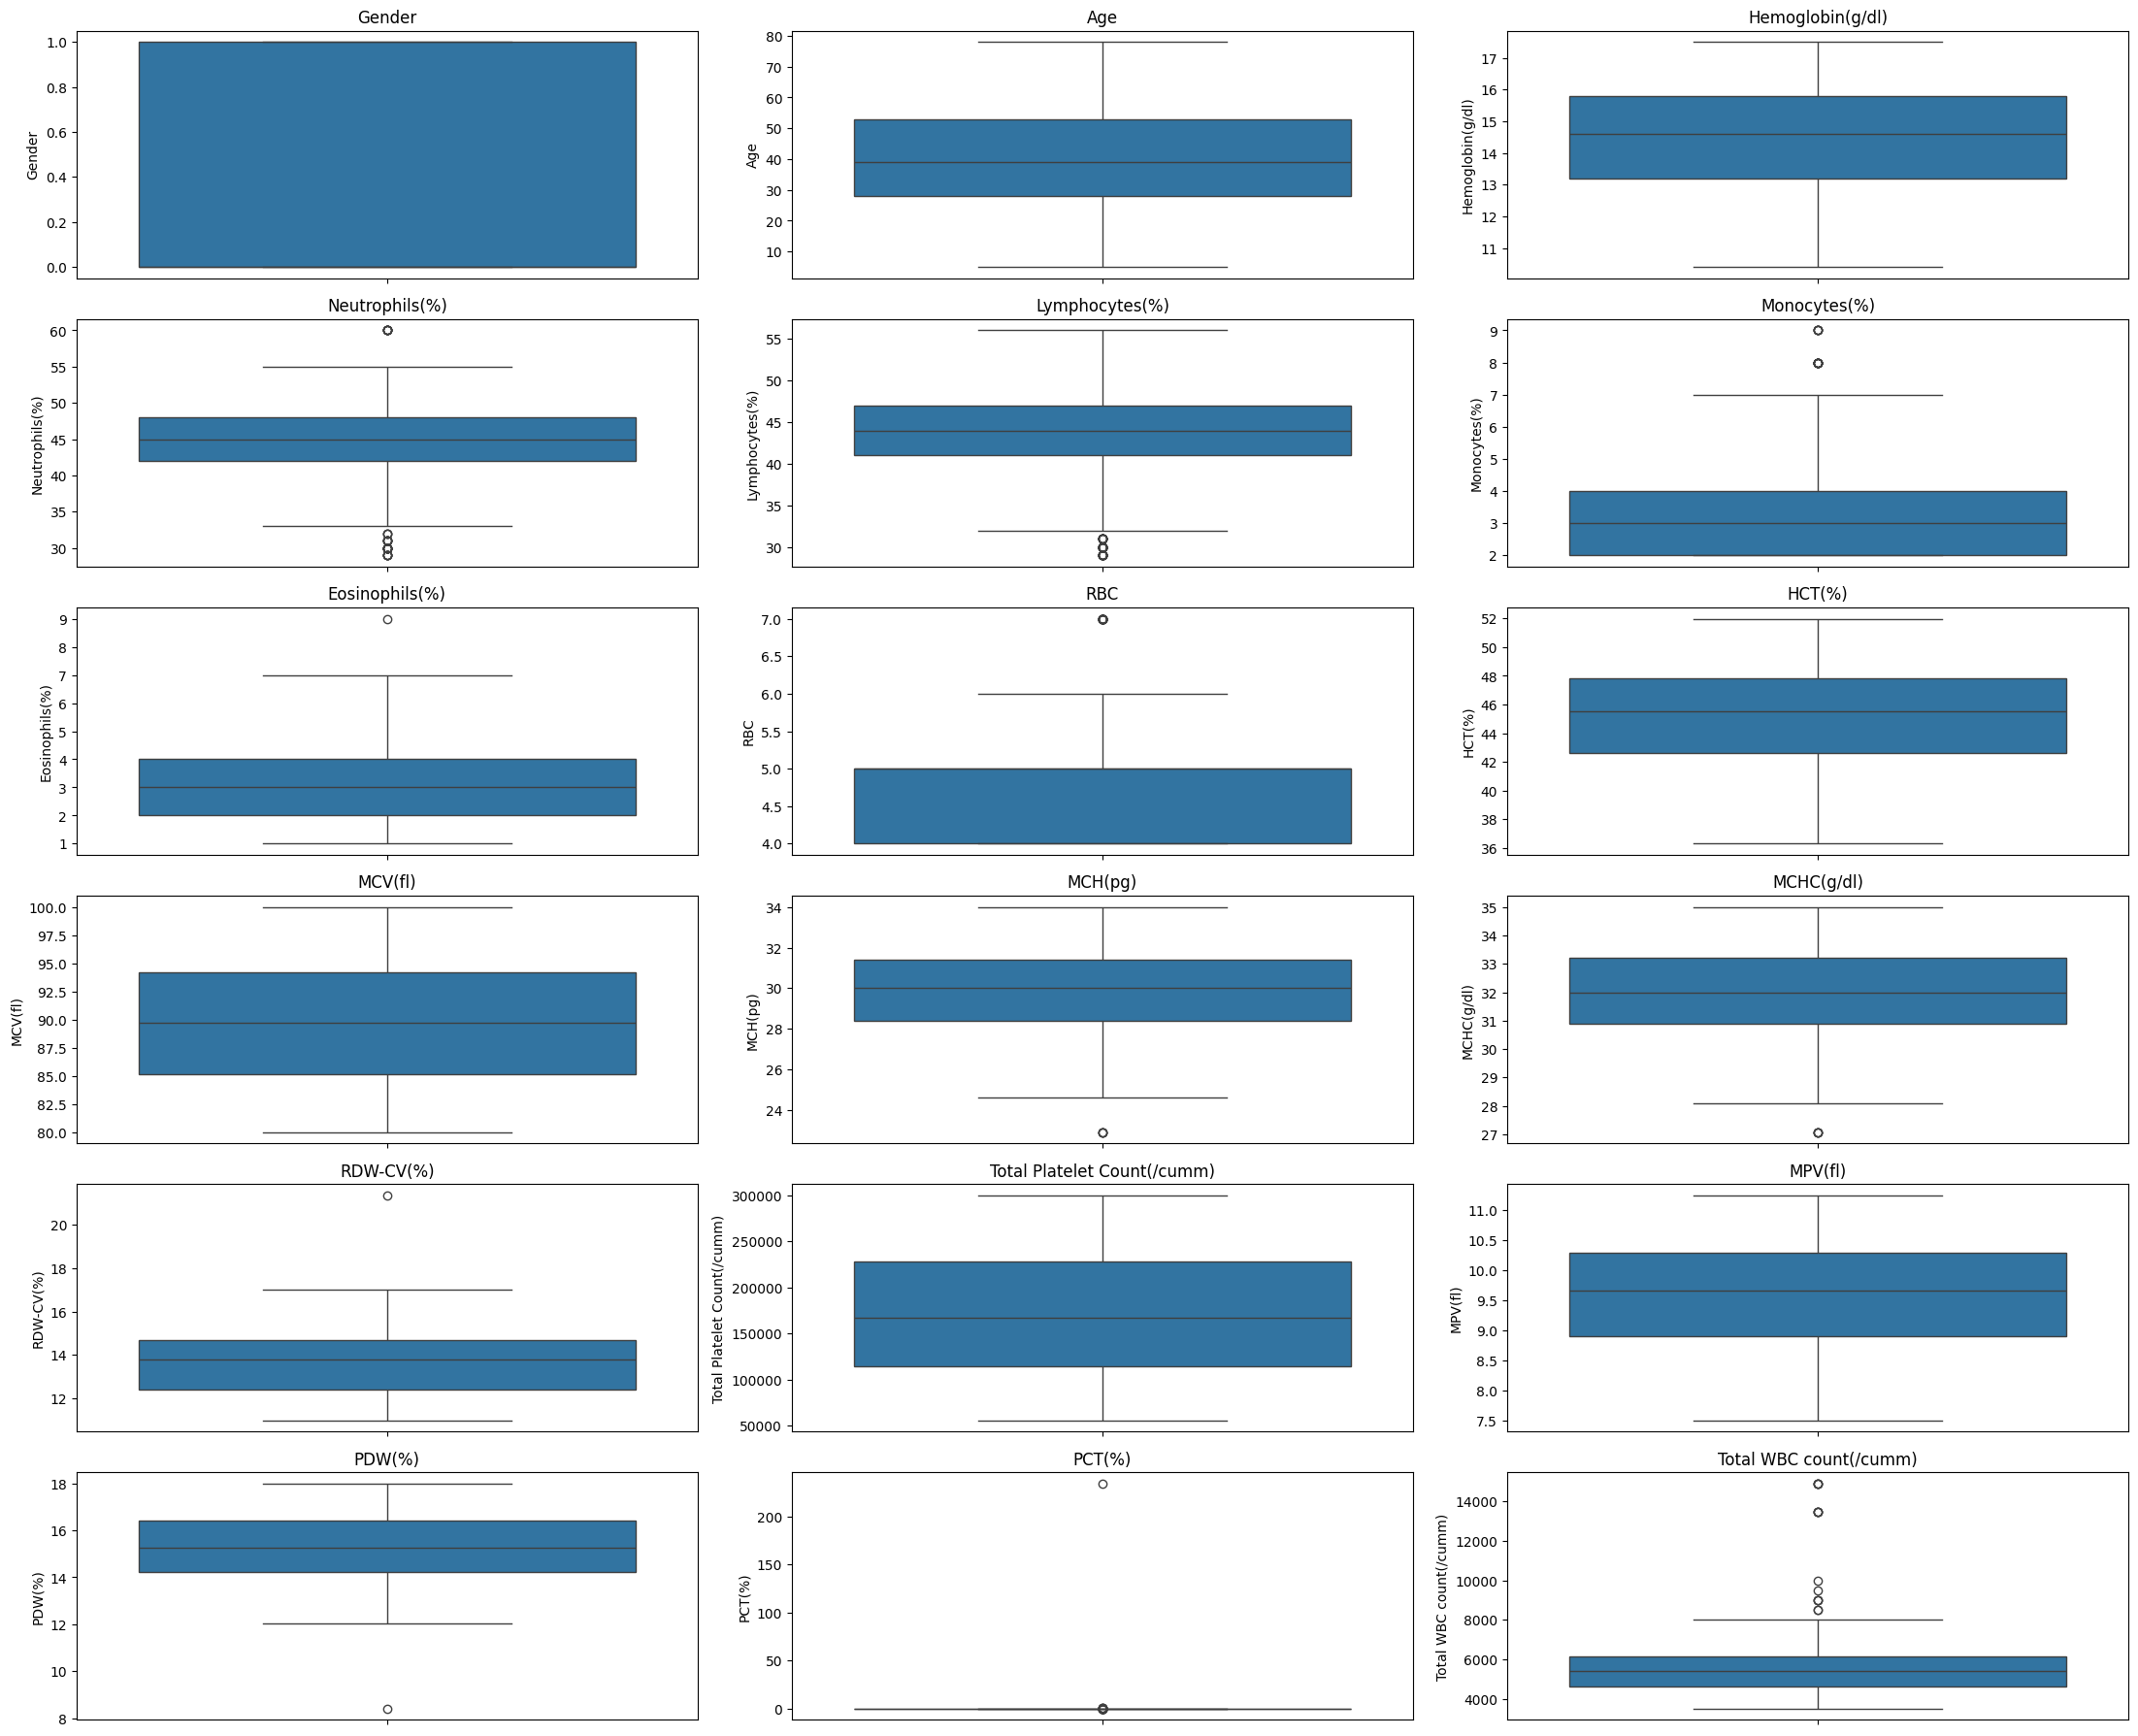

In [9]:
numerical_columns = X.columns

plt.figure(figsize=(22, 18))
for i, col in enumerate(numerical_columns):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [10]:
cols = ['Neutrophils(%)','Lymphocytes(%)','Monocytes(%)','Eosinophils(%)','RBC','MCH(pg)','MCHC(g/dl)', 'RDW-CV(%)', 'RDW-CV(%)','PDW(%)',]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[cols] < (Q1 - 1.5 * IQR)) |
                (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [11]:
print("Before:", df.shape[0])
print("After:", df_clean.shape[0])
print("Removed:", df.shape[0] - df_clean.shape[0])

Before: 1523
After: 1372
Removed: 151


In [12]:
from imblearn.combine import SMOTEENN

# Class balancing
smote_enn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train_scaled, y_train)
print(f"After SMOTEENN: {X_train_bal.shape}, positive: {sum(y_train_bal==1)}, negative: {sum(y_train_bal==0)}")

After SMOTEENN: (893, 18), positive: 298, negative: 595


In [13]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("🌲 Random Forest Results:")
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

🌲 Random Forest Results:
Accuracy: 71.80%

Confusion Matrix:
[[ 31  61]
 [ 25 188]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.34      0.42        92
           1       0.76      0.88      0.81       213

    accuracy                           0.72       305
   macro avg       0.65      0.61      0.62       305
weighted avg       0.69      0.72      0.69       305



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
🏆 Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

🌟 Tuned Random Forest Accuracy:
75.74%


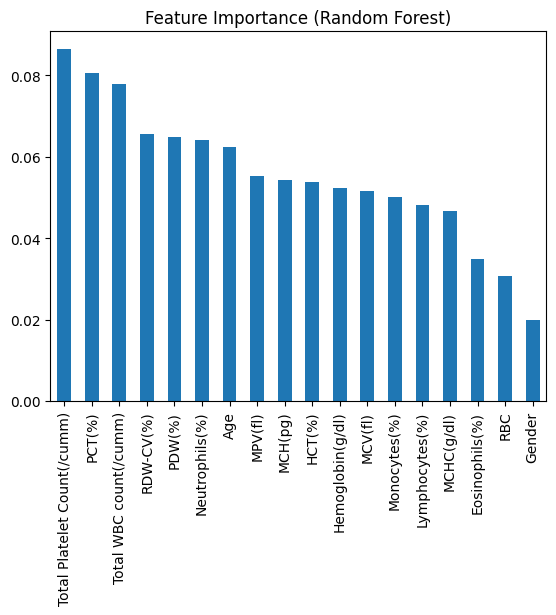

In [15]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("🏆 Best Parameters:")
print(grid_search.best_params_)

# Predictions
y_pred = best_rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n🌟 Tuned Random Forest Accuracy:")
print(f"{accuracy * 100:.2f}%")


import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.show()

Data shape:
(1218, 18) (305, 18)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

🏆 Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'bootstrap': True}

🌟 Test Accuracy:
78.36%

📊 Confusion Matrix:
[[ 37  59]
 [  7 202]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.39      0.53        96
           1       0.77      0.97      0.86       209

    accuracy                           0.78       305
   macro avg       0.81      0.68      0.69       305
weighted avg       0.80      0.78      0.76       305


📌 OOB Score: 0.777504105090312


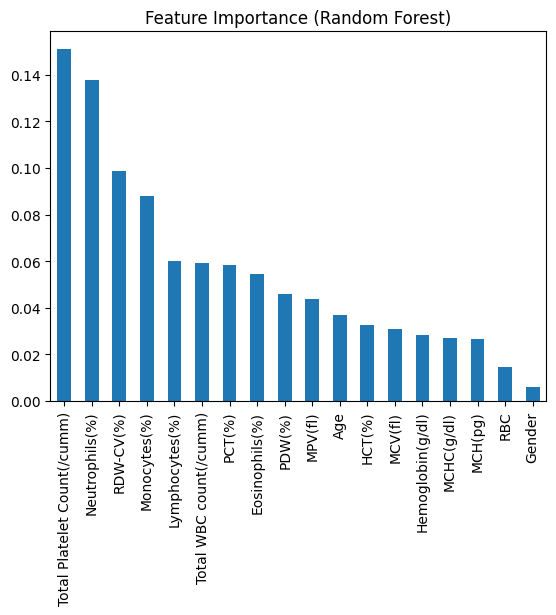

In [17]:
############
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Train-Test Split
# =========================
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data shape:")
print(X_train.shape, X_test.shape)

# =========================
# 2. Random Forest Model
# =========================
rf = RandomForestClassifier(random_state=42)

# =========================
# 3. Hyperparameter Space
# =========================
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# =========================
# 4. Randomized Search CV
# =========================
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("\n🏆 Best Parameters:")
print(random_search.best_params_)

# =========================
# 5. Prediction & Accuracy
# =========================
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🌟 Test Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 6. OOB Score (Optional check)
# =========================
if best_rf.bootstrap:
    best_rf.set_params(oob_score=True)
    best_rf.fit(X_train, y_train)
    print("\n📌 OOB Score:", best_rf.oob_score_)

# =========================
# 7. Feature Importance
# =========================
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
feature_importance.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [21]:
!pip install scikit-optimize
######################
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. Train-Test Split
# =========================
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data shape:", X_train.shape, X_test.shape)

# =========================
# 2. Model
# =========================
rf = RandomForestClassifier(random_state=42)

# =========================
# 3. Search Space (Bayesian)
# =========================
search_space = {
    'n_estimators': Integer(100, 600),
    'max_depth': Integer(5, 60),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2', None]),
    'bootstrap': Categorical([True, False])
}

# =========================
# 4. Bayesian Optimization
# =========================
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=search_space,
    n_iter=30,          # number of evaluations (increase for better result)
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

opt.fit(X_train, y_train)

best_rf = opt.best_estimator_

print("\n🏆 Best Parameters:")
print(opt.best_params_)

# =========================
# 5. Prediction
# =========================
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🌟 Test Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00
Data shape: (1218, 18) (305, 18)
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fi